# Data Prep

* View data_prep folder and pipeline file for detailed info
* Parameter to change on new Data: constants.py with cols and paths,
also fail_on_duplcate must be set to true if duplicated values are viewed to be an error (timestamps are always errors).

In [2]:
print("test")

test


In [3]:
from pathlib import Path
import sys

# Ensure the project src/ directory is importable from the notebook.
_cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    p for p in [_cwd, *_cwd.parents] if (p / "src" / "timeseries_forecast").exists()
)
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from timeseries_forecast.data_prep.raw_data import read_raw_metals_data
from timeseries_forecast.data_prep.pipeline import run_data_pipeline
from timeseries_forecast.data_prep.data_merge import merge_all_raw_data
from timeseries_forecast.data_prep.constants import RawMetalsColumn

# from timeseries_forecast.feature import autoregressive_features
# from timeseries_forecast.eval.eval import evaluate, evaluate_predictions
# from timeseries_forecast.feature.custom_features import add_log_ret_features
# from timeseries_forecast.feature import engineer_features
# from timeseries_forecast.config.feature_config import FeatureConfig
# from timeseries_forecast.data_prep.data_resample import resample_dataframe_with_aggregations

In [4]:
alu_df = read_raw_metals_data("aluminium")
alu_df.Date

0      2024-08-29
1      2024-08-28
2      2024-08-27
3      2024-08-26
4      2024-08-23
          ...    
2730   2014-01-07
2731   2014-01-06
2732   2014-01-03
2733   2014-01-02
2734   2014-01-01
Name: Date, Length: 2735, dtype: datetime64[us]

## Cleaning for all metals with same parameters

### Aluminium

In [5]:
aluminium_df_cleaned = run_data_pipeline(
    read_raw_metals_data("aluminium"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])
aluminium_df_cleaned


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 4 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2020-09-29', '2020-09-30', '2024-07-30', '2024-07-31'], dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1159 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 15 NaN-Werte insgesamt gefunden:
  Vol.: 15 (0.55%)

0-Werte Check
WARN: 32 0-Werte insgesamt gefunden:
  Vol.: 32 (1.17%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,735 Zeilen
  Zu ergänzende Einträge: 1,159
    RawMetalsColumn.VOLUME: 32 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1159 -> 0 NaN
    Open: 1159 -> 0 NaN
    High: 1159 -> 0 NaN
    Low: 1159 -> 0 NaN
    Vol.: 1206 -> 0 NaN
    Change %: 1159 -> 0 NaN

  Shape vorher:  (2735, 6)
  Shape nachher: (3894, 6)
OK: Interpola

,Close,Open,High,Low,Vol.,Mode
2014-01-01,110.10,110.000000,110.700000,109.900000,450.000000,Train
2014-01-02,111.20,110.550000,112.200000,110.450000,4720.000000,Train
2014-01-03,109.20,110.900000,111.100000,109.050000,4520.000000,Train
2014-01-04,109.35,110.433333,110.650000,108.733333,4333.333333,Train
2014-01-05,109.50,109.966667,110.200000,108.416667,4146.666667,Train
...,...,...,...,...,...,...
2024-08-25,229.60,229.450000,232.433333,227.483333,1236.666667,Test
2024-08-26,229.50,230.850000,233.500000,228.850000,510.000000,Test
2024-08-27,231.55,229.000000,233.000000,228.200000,60.000000,Test
2024-08-28,232.05,233.400000,233.400000,231.400000,35.000000,Test


In [6]:
# alu_df_cleaned.loc["25-08-2024"]

### Copper

In [7]:
copper_df_cleaned = run_data_pipeline(
    read_raw_metals_data("copper"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 20 NaN-Werte insgesamt gefunden:
  Vol.: 20 (0.73%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1161 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3894, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### gold

In [8]:
gold_df_cleaned = run_data_pipeline(
    read_raw_metals_data("gold"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1135 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 22 NaN-Werte insgesamt gefunden:
  Vol.: 22 (0.80%)

0-Werte Check
WARN: 7 0-Werte insgesamt gefunden:
  Vol.: 7 (0.25%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,760 Zeilen
  Zu ergänzende Einträge: 1,135
    RawMetalsColumn.VOLUME: 7 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1135 -> 0 NaN
    Open: 1135 -> 0 NaN
    High: 1135 -> 0 NaN
    Low: 1135 -> 0 NaN
    Vol.: 1164 -> 0 NaN
    Change %: 1135 -> 0 NaN

  Shape vorher:  (2760, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### lead

In [9]:
lead_df_cleaned = run_data_pipeline(
    read_raw_metals_data("lead"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
    fail_on_row_duplicates=False,
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 6 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2023-03-29', '2023-03-30', '2023-07-27', '2023-07-28',
               '2024-02-26'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 31 NaN-Werte insgesamt gefunden:
  Vol.: 31 (1.12%)

0-Werte Check
WARN: 45 0-Werte insgesamt gefunden:
  Vol.: 45 (1.63%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,757 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 45 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1213 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2757, 

### nickel

In [10]:
nickel_df_cleaned = run_data_pipeline(
    read_raw_metals_data("nickel"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])
nickel_df_cleaned


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
WARN: 21 Zeilen sind doppelt (identischer Inhalt)
  Beispiele (erste 5 Timestamps):
DatetimeIndex(['2022-05-27', '2022-05-30', '2022-05-31', '2022-06-02',
               '2022-06-03'],
              dtype='datetime64[us]', name='RawMetalsColumn.OPEN_TIME', freq=None)

Fehlende Werte Check
WARN: Es gibt 1139 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 580 NaN-Werte insgesamt gefunden:
  Vol.: 580 (21.05%)

0-Werte Check
WARN: 40 0-Werte insgesamt gefunden:
  Open: 1 (0.04%)
  High: 1 (0.04%)
  Low: 1 (0.04%)
  Vol.: 37 (1.34%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,894 Einträge
  Aktueller DataFrame:    2,755 Zeilen
  Zu ergänzende Einträge: 1,139
    RawMetalsColumn.VOLUME: 37 Nullwerte -> NaN ersetzt
    RawMetalsColumn.OPEN: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.HIGH: 1 Nullwerte -> NaN ersetzt
    RawMetalsColumn.LOW: 1 Nullwerte -> NaN erse

,Close,Open,High,Low,Vol.,Mode
2014-01-01,866.100000,867.000000,869.900000,863.000000,2430.000000,Train
2014-01-02,875.200000,869.900000,880.500000,862.600000,20390.000000,Train
2014-01-03,865.100000,873.100000,875.000000,863.500000,13910.000000,Train
2014-01-04,865.100000,865.100000,865.100000,865.100000,16163.333333,Train
2014-01-05,858.100000,866.300000,867.200000,856.100000,18416.666667,Train
...,...,...,...,...,...,...
2024-08-25,1415.833333,1415.833333,1415.833333,1415.833333,20.000000,Test
2024-08-26,1420.400000,1420.400000,1420.400000,1420.400000,20.000000,Test
2024-08-27,1420.400000,1420.400000,1420.400000,1420.400000,20.000000,Test
2024-08-28,1438.000000,1438.000000,1438.000000,1438.000000,20.000000,Test


### silver

In [11]:
silver_df_cleaned = run_data_pipeline(
    read_raw_metals_data("silver"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[
        RawMetalsColumn.VOLUME,
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1136 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 18 NaN-Werte insgesamt gefunden:
  Vol.: 18 (0.65%)

0-Werte Check
WARN: 5 0-Werte insgesamt gefunden:
  Vol.: 5 (0.18%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,759 Zeilen
  Zu ergänzende Einträge: 1,136
    RawMetalsColumn.VOLUME: 5 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1136 -> 0 NaN
    Open: 1136 -> 0 NaN
    High: 1136 -> 0 NaN
    Low: 1136 -> 0 NaN
    Vol.: 1159 -> 0 NaN
    Change %: 1136 -> 0 NaN

  Shape vorher:  (2759, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe 

### zinc

In [12]:
zinc_df_cleaned = run_data_pipeline(
    read_raw_metals_data("zinc"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[RawMetalsColumn.PCT_CHANGE],
    zero_as_nan_cols=[RawMetalsColumn.VOLUME],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1137 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 19 NaN-Werte insgesamt gefunden:
  Vol.: 19 (0.69%)

0-Werte Check
WARN: 13 0-Werte insgesamt gefunden:
  Vol.: 13 (0.47%)

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 3,895 Einträge
  Aktueller DataFrame:    2,758 Zeilen
  Zu ergänzende Einträge: 1,137
    RawMetalsColumn.VOLUME: 13 Nullwerte -> NaN ersetzt

  Interpoliere 6 numerische Spalten:
    Price: 1137 -> 0 NaN
    Open: 1137 -> 0 NaN
    High: 1137 -> 0 NaN
    Low: 1137 -> 0 NaN
    Vol.: 1169 -> 0 NaN
    Change %: 1137 -> 0 NaN

  Shape vorher:  (2758, 6)
  Shape nachher: (3895, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitrei

## SP 500

In [13]:
sp500_df_cleaned = run_data_pipeline(
    read_raw_metals_data("sp500"),
    timestamp_column=RawMetalsColumn.OPEN_TIME,
    data_freq="D",
    split_train_end="2019-12-31",
    split_val_end="2021-12-31",
    zero_value_ignore_cols=[
        RawMetalsColumn.PCT_CHANGE,
        RawMetalsColumn.VOLUME],
    zero_as_nan_cols=[
        RawMetalsColumn.OPEN,
        RawMetalsColumn.HIGH,
        RawMetalsColumn.LOW,
    ],
).rename(columns={RawMetalsColumn.PRICE: "Close"}).drop(columns=[RawMetalsColumn.PCT_CHANGE]).drop(columns=[RawMetalsColumn.VOLUME])


Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
WARN: Es gibt 1602 Lücken in der Zeitreihe (erwartete Frequenz: D).

NaN-Check
WARN: 3540 NaN-Werte insgesamt gefunden:
  Vol.: 3540 (99.97%)

0-Werte Check
OK: Keine 0-Werte gefunden!

Data Cleaning – Interpolation von Missing Values und Nullwerten

  Vollständiger Zeitindex: 5,143 Einträge
  Aktueller DataFrame:    3,541 Zeilen
  Zu ergänzende Einträge: 1,602

  Interpoliere 6 numerische Spalten:
    Price: 1602 -> 0 NaN
    Open: 1602 -> 0 NaN
    High: 1602 -> 0 NaN
    Low: 1602 -> 0 NaN
    Vol.: 5142 -> 0 NaN
    Change %: 1602 -> 0 NaN

  Shape vorher:  (3541, 6)
  Shape nachher: (5143, 6)
OK: Interpolation abgeschlossen!

Duplikat-Check
OK: Keine doppelten Zeitstempel im Index
OK: Keine identischen Zeilenduplikate gefunden

Fehlende Werte Check
OK: Keine Lücken in der Zeitreihe gefunden (Frequenz: D).

NaN-Check
OK: Keine NaN-Werte gefunden!

0-Werte Ch

## Merge

In [14]:
merged_df = merge_all_raw_data(
    aluminium_df_cleaned=aluminium_df_cleaned,
    copper_df_cleaned=copper_df_cleaned,
    gold_df_cleaned=gold_df_cleaned,
    lead_df_cleaned=lead_df_cleaned,
    nickel_df_cleaned=nickel_df_cleaned,
    silver_df_cleaned=silver_df_cleaned,
    zinc_df_cleaned=zinc_df_cleaned,
    sp500_df_cleaned=sp500_df_cleaned,
)

In [15]:
df = merged_df.copy()
df.columns

Index(['ALU_Close', 'ALU_Open', 'ALU_High', 'ALU_Low', 'ALU_Vol.', 'ALU_Mode',
       'COPPER_Close', 'COPPER_Open', 'COPPER_High', 'COPPER_Low',
       'COPPER_Vol.', 'COPPER_Mode', 'GOLD_Close', 'GOLD_Open', 'GOLD_High',
       'GOLD_Low', 'GOLD_Vol.', 'GOLD_Mode', 'LEAD_Close', 'LEAD_Open',
       'LEAD_High', 'LEAD_Low', 'LEAD_Vol.', 'LEAD_Mode', 'NICKEL_Close',
       'NICKEL_Open', 'NICKEL_High', 'NICKEL_Low', 'NICKEL_Vol.',
       'NICKEL_Mode', 'SILVER_Close', 'SILVER_Open', 'SILVER_High',
       'SILVER_Low', 'SILVER_Vol.', 'SILVER_Mode', 'ZINC_Close', 'ZINC_Open',
       'ZINC_High', 'ZINC_Low', 'ZINC_Vol.', 'ZINC_Mode', 'SP500_Close',
       'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Mode'],
      dtype='str')

In [16]:
# # Test the function
# frequency_resample = '1h'

# resampled = resample_dataframe_with_aggregations(df, frequency_resample)
# print(f"Original shape: {df.shape}")
# print(f"Resampled {frequency_resample} shape: {resampled.shape}")
# print(f"\nFirst few rows of resampled data:")
# print(resampled.head())

In [17]:
# df = resampled.copy()

In [18]:
# models = [
#     # RandomForestRegressor(random_state=42),
#     # DecisionTreeRegressor(random_state=42),
#     SVR(),
#     LinearSVR(random_state=42),
#     LGBMRegressor(random_state=42),
#     XGBRegressor(random_state=42),
#     LinearRegression(),
#     KNeighborsRegressor()
# ]

In [19]:
# fügt eine type spalte als label (target) hinzu
# macht die timestamp spalte explizit, damit man daraus infos extrahieren kann

df["type"] = "Aluminium"
df["timestamp"] = df.index

In [20]:
# add log ret features
from timeseries_forecast.feature.custom_features import add_log_ret_features

feature_df, feature_name_btc_log_ret = add_log_ret_features(df, "ALU_Close")
#feature_df, feature_name_eth_log_ret = add_log_ret_features(feature_df, "ETH_Close")

In [21]:
# feature_df.columns

In [22]:
#without mode

numeric_feature_columns = ['ALU_Close', 'ALU_Open', 'ALU_High', 'ALU_Low',
       'ALU_Vol.', 'COPPER_Close', 'COPPER_Open',
       'COPPER_High', 'COPPER_Low', 'COPPER_Vol.', 'GOLD_Close',
       'GOLD_Open', 'GOLD_High', 'GOLD_Low', 'GOLD_Vol.',
       'LEAD_Close', 'LEAD_Open', 'LEAD_High', 'LEAD_Low', 'LEAD_Vol.',
       'NICKEL_Close', 'NICKEL_Open', 'NICKEL_High', 'NICKEL_Low',
       'NICKEL_Vol.', 'SILVER_Close', 'SILVER_Open',
       'SILVER_High', 'SILVER_Low', 'SILVER_Vol.', 'ZINC_Close',
       'ZINC_Open', 'ZINC_High', 'ZINC_Low', 'ZINC_Vol.', 'SP500_Close',
       'SP500_Open', 'SP500_High', 'SP500_Low'
       ]

# Feature Engineering

### Lag Features

lag features sind die Features, die die Werte von den Vorherigen Zeilen annehemn, hier wird durch lag_window_len festgelegt, wie weit dies in die Zukunft gelegt werden soll. Zb bei einer täglichen Frequency und bei einer lag_window_len = 12, werden für jeden Wert die Werte der letzten 12 Tage gespeichert. 

In [23]:
from timeseries_forecast.feature import engineer_features
lag_window_len = 12

lag = list(range(1, lag_window_len + 1))

features = []
for column in numeric_feature_columns:
    features.append(
        engineer_features.LaggingFeatures
        (
            column=column, 
            lags=lag,
         
        )
    )
    

### Rolling Features

In [24]:
for column in numeric_feature_columns:
    features.append(
        engineer_features.RollingFeatures
        (
            column=column, 
            rolls=[3, 6, 12],
            agg_funcs=["mean", "std", "min", "max"]
        )
    )

### Temporal Features

In [25]:
# features.append(
#     engineer_features.TemporalFeatures
#     (
#         column="timestamp",
#         frequency="24h"
#     )
# )

# print("✓ Temporal features added")

### Fourier Features (Seasonal Patterns)

In [26]:
# # Add Fourier features for capturing seasonal patterns in the data
# # These are useful for recurring patterns like yearly seasonality
# features.append(
#     engineer_features.FourierFeatures
#     (
#         column="timestamp",
#         max_value=365,  # Yearly seasonality (365 daily observations per year)
#         n_fourier_terms=4  # 4 sine and 4 cosine terms
#     )
# )

# print("✓ Fourier features added (yearly seasonality with 4 terms)")

# Feature Definition

In [27]:
from timeseries_forecast.config.feature_config import FeatureConfig 
from timeseries_forecast.data_prep.data_resample import resample_dataframe_with_aggregations
import pandas as pd

def define_features(df: pd.DataFrame, forecast_horizon: int):
    feature_engineer = engineer_features.FeatureEngineeringConfig(features=features)
    features_df, added_features = feature_engineer.create_features(df, forecast_horizon)

    #this line adds contemp eth log return as feature
    #added_features.extend(feature_name_eth_log_ret)

    feat_config = FeatureConfig(
        date="timestamp",
        target="ALU_Close",
        continuous_features=added_features,
        categorical_features=[],
        boolean_features=[],
        index_cols=["type","timestamp"],
        exogenous_features=[],
    )

    return feat_config, features_df

OK: Function 'resample_dataframe_with_aggregations' defined


In [28]:
#forecast horizon defined here 
feature_config, features_df = define_features(feature_df, forecast_horizon=1)

C:\Users\Acer\Desktop\OTH\FPP\fpp\src\timeseries_forecast\feature\autoregressive_features.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(**col_dict)
C:\Users\Acer\Desktop\OTH\FPP\fpp\src\timeseries_forecast\feature\autoregressive_features.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df = df.assign(**col_dict)
C:\Users\Acer\Desktop\OTH\FPP\fpp\src\timeseries_forecast\feature\autoregressive_features.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame

In [29]:
df_train = features_df[features_df["ALU_Mode"] == "Train"].dropna()
df_val = features_df[features_df["ALU_Mode"] == "Val"]
df_test = features_df[features_df["ALU_Mode"] == "Test"]

## Correlation Analysis

To keep the plot readable with many features, only the strongest positive and negative correlations with the target are shown here.

,top_positive,top_negative
ALU_Close_lag_1,0.997585,NaN
ALU_Close_lag_2,0.994879,NaN
ALU_Close_rolling_3_max,0.995612,NaN
ALU_Close_rolling_3_mean,0.995882,NaN
ALU_Close_rolling_3_min,0.994876,NaN
ALU_High,0.998330,NaN
ALU_High_lag_1,0.995625,NaN
ALU_Low,0.998532,NaN
ALU_Low_lag_1,0.996165,NaN
ALU_Low_rolling_3_max,0.994359,NaN


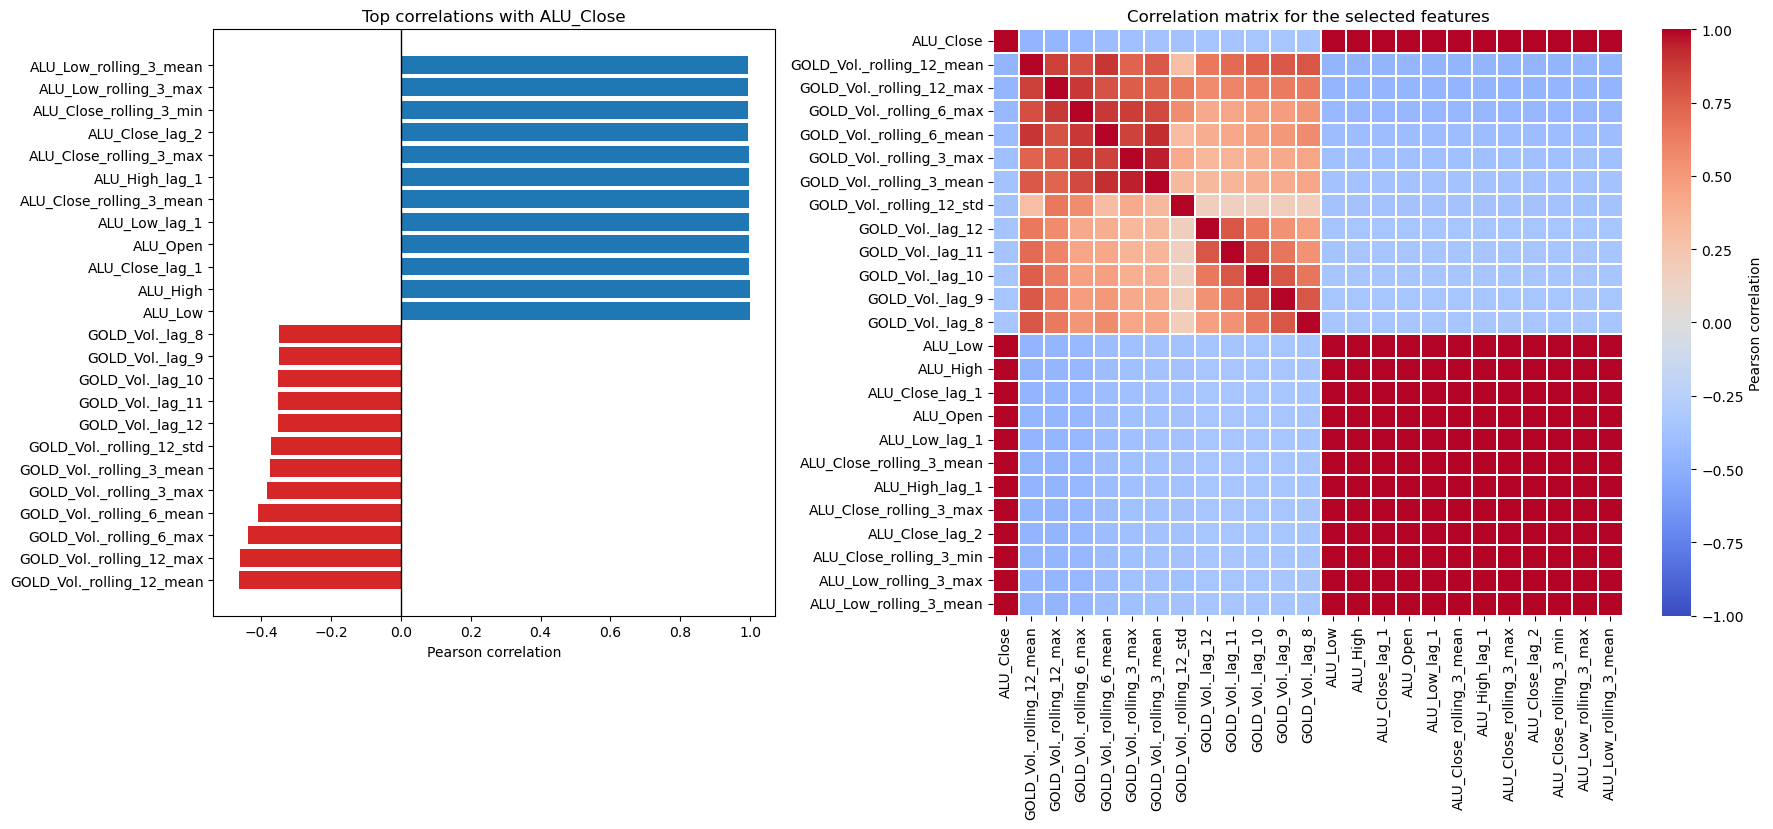

In [30]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def plot_top_correlations(df: pd.DataFrame, target_col: str, top_n: int = 10):
    numeric_df = df.select_dtypes(include="number").copy()
    if target_col not in numeric_df.columns:
        raise ValueError(f"'{target_col}' must be a numeric column in the dataframe.")

    # Compute only feature-vs-target correlations first so we avoid an expensive full 800x800 matrix.
    feature_only = numeric_df.drop(columns=[target_col])
    corr_with_target = feature_only.corrwith(numeric_df[target_col]).dropna().sort_values()

    top_negative = corr_with_target.head(top_n)
    top_positive = corr_with_target.tail(top_n).sort_values(ascending=False)

    selected_features = pd.Index(top_negative.index.tolist() + top_positive.index.tolist()).unique()
    selected_columns = [target_col, *selected_features.tolist()]
    corr_matrix = numeric_df[selected_columns].corr()

    ranked = pd.concat([top_negative, top_positive])
    fig_height = max(6, 0.35 * len(ranked))
    fig, (ax_bar, ax_heatmap) = plt.subplots(
        1,
        2,
        figsize=(18, fig_height),
        gridspec_kw={"width_ratios": [1, 1.4]},
    )

    colors = ["#d62728" if value < 0 else "#1f77b4" for value in ranked.values]
    ax_bar.barh(ranked.index, ranked.values, color=colors)
    ax_bar.axvline(0, color="black", linewidth=1)
    ax_bar.set_title(f"Top correlations with {target_col}")
    ax_bar.set_xlabel("Pearson correlation")
    ax_bar.set_ylabel("")

    sns.heatmap(
        corr_matrix,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        linewidths=0.3,
        cbar_kws={"label": "Pearson correlation"},
        ax=ax_heatmap,
    )
    ax_heatmap.set_title("Correlation matrix for the selected features")

    plt.tight_layout()

    summary = pd.DataFrame(
        {
            "top_positive": top_positive,
            "top_negative": top_negative,
        }
    )

    return summary, corr_matrix


target_column = "ALU_Close"
correlation_summary, correlation_matrix = plot_top_correlations(df_train, target_column, top_n=12)
display(correlation_summary)

In [31]:
train_features, train_target, _ = feature_config.get_X_y(df_train)
val_features, val_target, _ = feature_config.get_X_y(df_val)
test_features, test_target, _ = feature_config.get_X_y(df_test)

## Simple ALU Price Plots

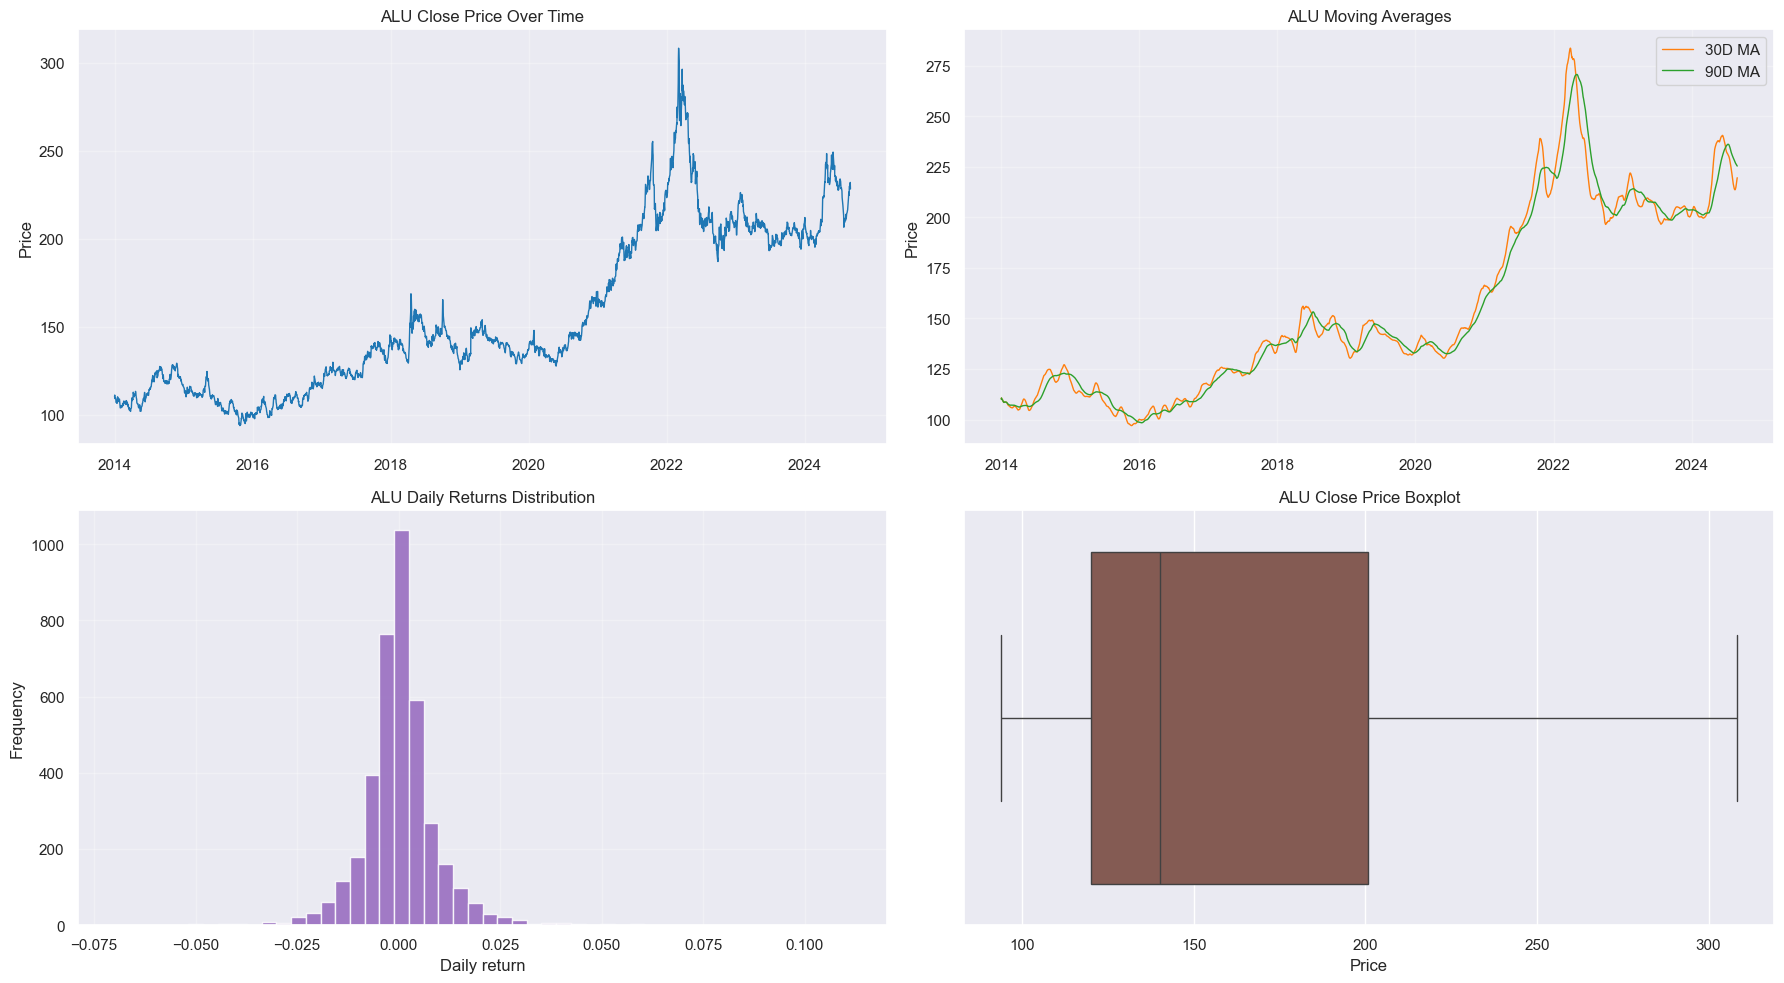

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

alu_plot_df = feature_df[["timestamp", "ALU_Close"]].dropna().sort_values("timestamp").copy()
alu_plot_df = alu_plot_df.set_index("timestamp")
alu_plot_df["ALU_Close_Return"] = alu_plot_df["ALU_Close"].pct_change()
alu_plot_df["ALU_Close_Rolling_30"] = alu_plot_df["ALU_Close"].rolling(30, min_periods=1).mean()
alu_plot_df["ALU_Close_Rolling_90"] = alu_plot_df["ALU_Close"].rolling(90, min_periods=1).mean()

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0, 0].plot(alu_plot_df.index, alu_plot_df["ALU_Close"], color="#1f77b4", linewidth=1)
axes[0, 0].set_title("ALU Close Price Over Time")
axes[0, 0].set_ylabel("Price")
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(alu_plot_df.index, alu_plot_df["ALU_Close_Rolling_30"], color="#ff7f0e", linewidth=1, label="30D MA")
axes[0, 1].plot(alu_plot_df.index, alu_plot_df["ALU_Close_Rolling_90"], color="#2ca02c", linewidth=1, label="90D MA")
axes[0, 1].set_title("ALU Moving Averages")
axes[0, 1].set_ylabel("Price")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].hist(alu_plot_df["ALU_Close_Return"].dropna(), bins=50, color="#9467bd", alpha=0.85)
axes[1, 0].set_title("ALU Daily Returns Distribution")
axes[1, 0].set_xlabel("Daily return")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].grid(True, alpha=0.3)

sns.boxplot(x=alu_plot_df["ALU_Close"], ax=axes[1, 1], color="#8c564b")
axes[1, 1].set_title("ALU Close Price Boxplot")
axes[1, 1].set_xlabel("Price")

plt.tight_layout()
plt.show()